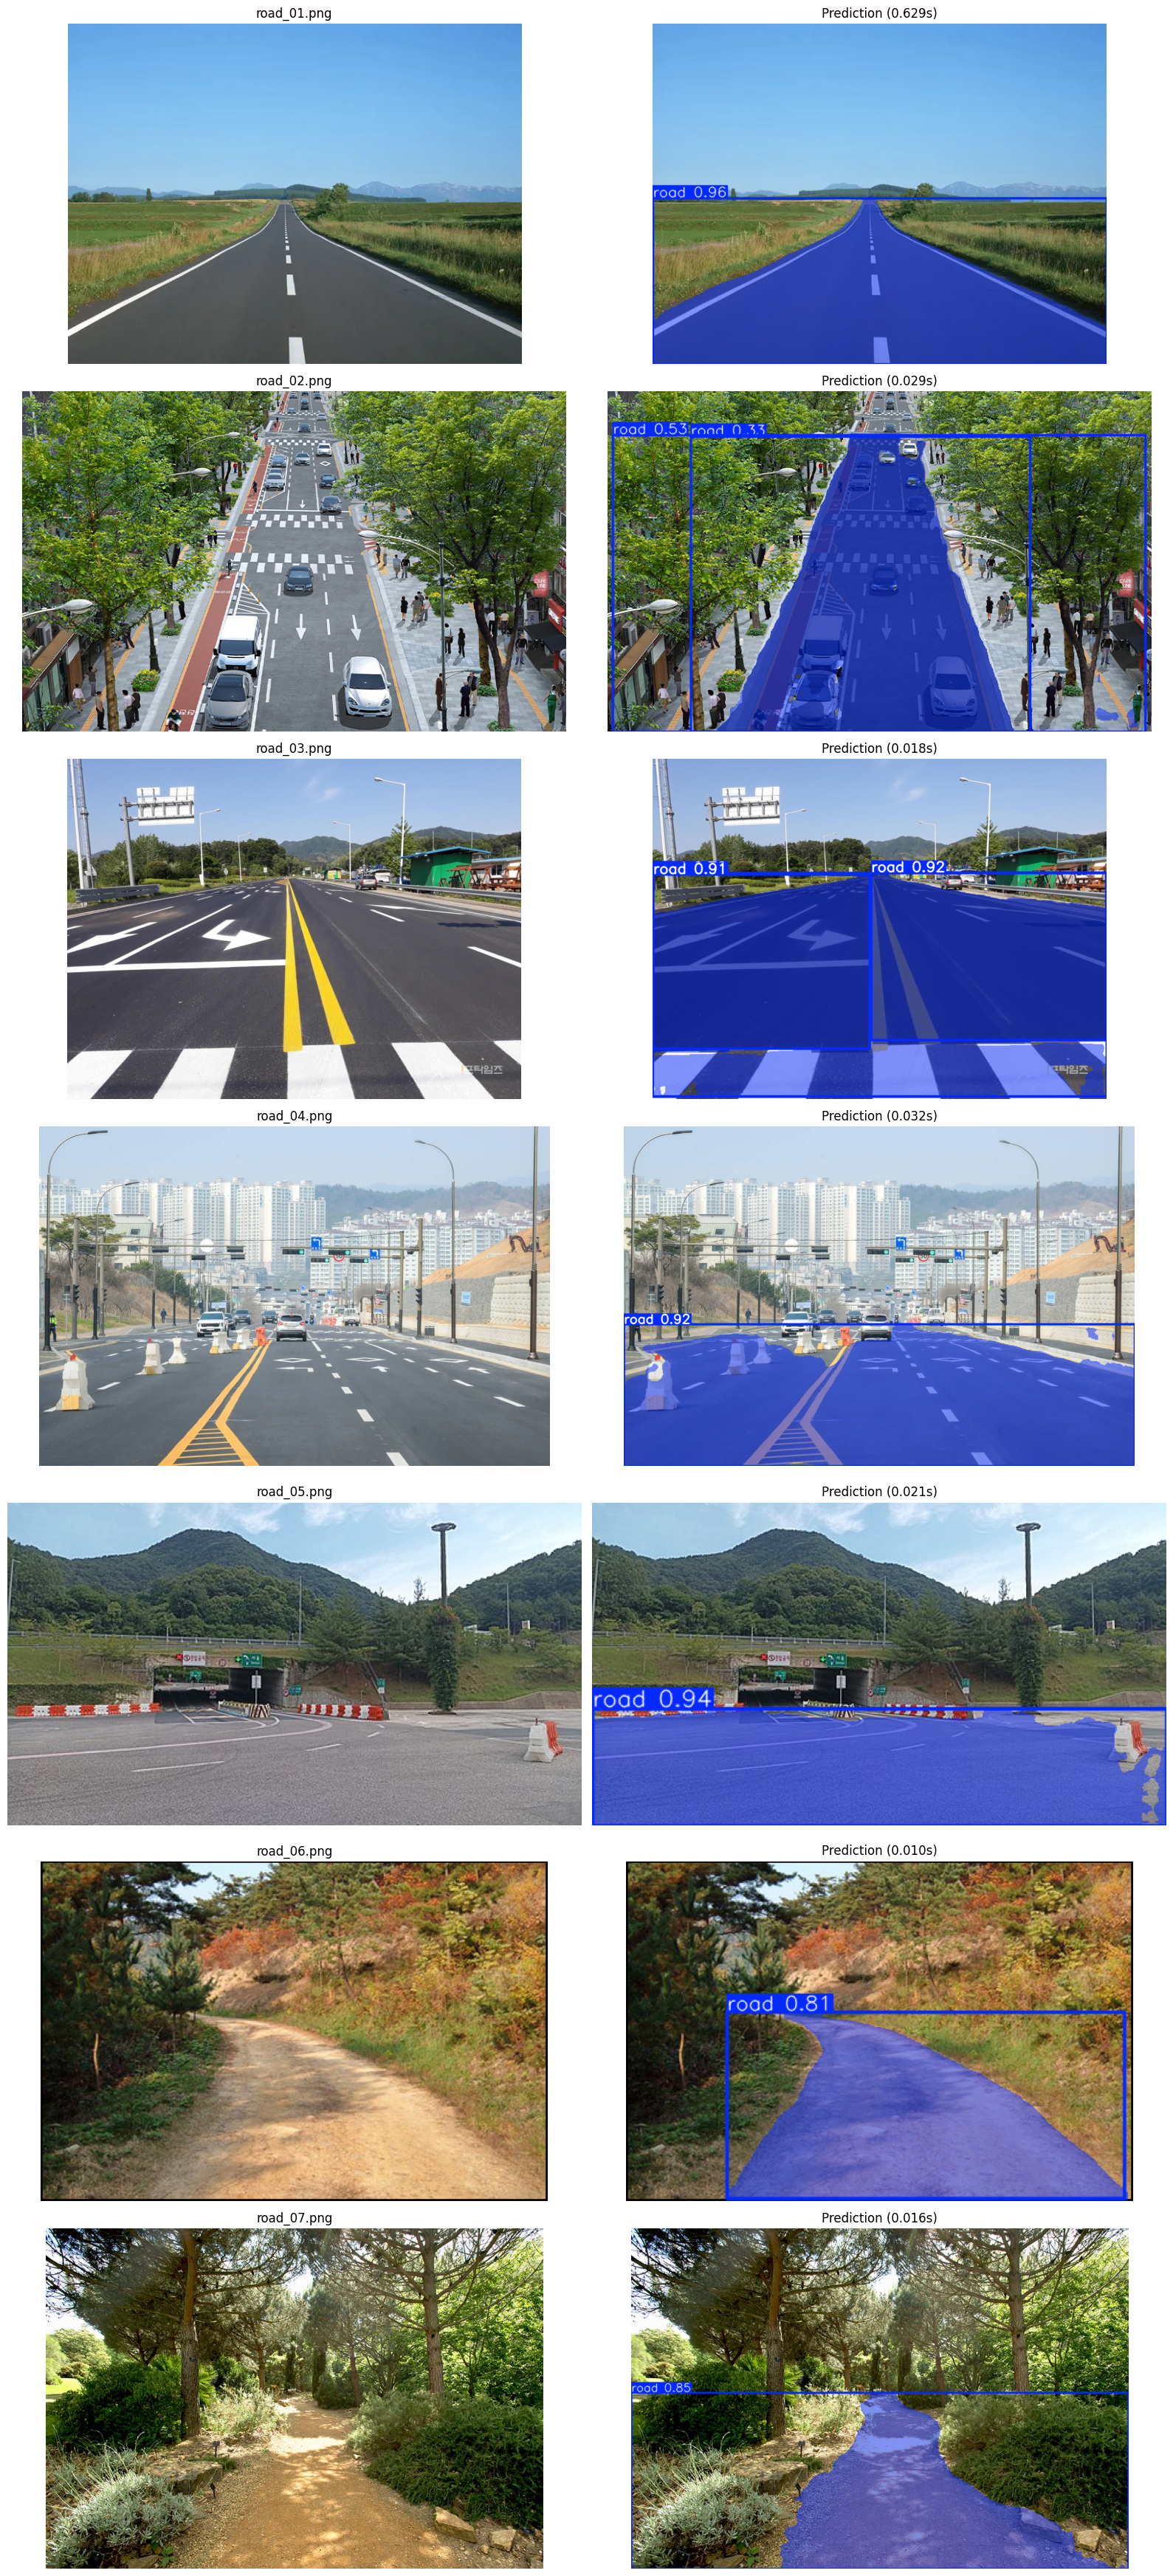

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import glob
import os
import time

model = YOLO("./model/01_yolo11m-road-sg.pt")

exts = {".jpg", ".jpeg", ".png", ".gif"}
image_files = sorted(
    str(p) for p in Path("./test_data_01_gen").rglob("*")
    if p.suffix.lower() in exts
)

fig, axes = plt.subplots( len(image_files), 2, figsize=(16, 5 * len(image_files)) )

if len(image_files) == 1:
    axes = [axes]

total_time = 0

for i, image_file in enumerate(image_files):

    filename = os.path.basename(image_file)

    # 원본 이미지
    original = cv2.imread(image_file)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # 추론 시간 측정
    start = time.time()
    result = model(image_file, verbose=False)[0]
    elapsed = time.time() - start

    total_time += elapsed 

    # 예측 결과
    predicted = result.plot()
    predicted = cv2.cvtColor(predicted, cv2.COLOR_BGR2RGB)

    axes[i][0].imshow(original)
    axes[i][0].set_title(filename)
    axes[i][0].axis("off")

    axes[i][1].imshow(predicted)
    axes[i][1].set_title(f"Prediction ({elapsed:.3f}s)")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show() 